In [1]:
###DA SISTEMARE E RUNNARE 

In [2]:
%matplotlib widget

In [3]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd

In [4]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/MGC+01-02-017/MGC+01-02-017_1/FORS2.2021-10-04T04_41_52.988/MCG+01-02-017_1_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data
image_error = hdul[1].data

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/MGC+01-02-017/MGC+01-02-017_1/FORS2.2021-10-04T04_41_52.988/MCG+01-02-017_1_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     361   (2094, 963)   float32   
  1  IMAGE.ERR     1 ImageHDU        42   (2094, 963)   float32   


In [5]:
image_cut = image[61:161, 0:1890]
image_error_cut = image_error[61:161, 0:1890]

Text(0.5, 0, 'wavelength')

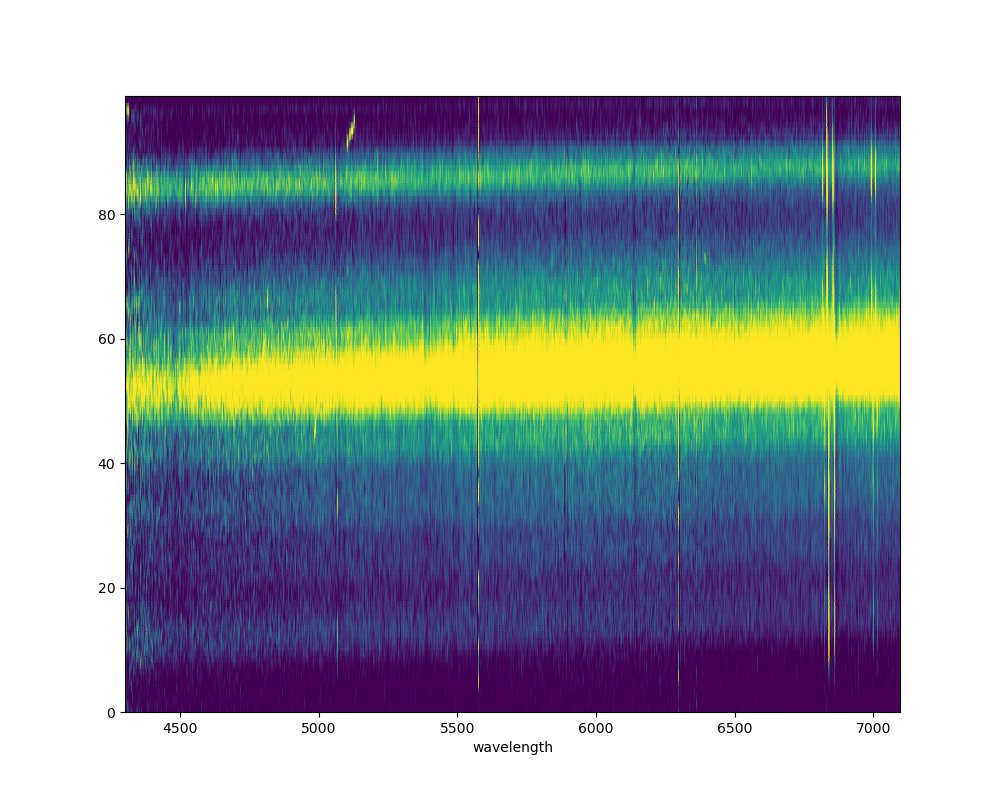

In [6]:
wv = np.arange(4300.74, 4300.74+1890*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

x_grid, y_grid = np.meshgrid(wv, y)
plt.figure(figsize=(10,8))
plt.pcolormesh(x_grid, y_grid, image_cut, shading='gouraud', vmin=np.percentile(image_cut, 15), vmax=np.percentile(image_cut, 90))
plt.xlabel('wavelength')

## Redshift or the lines in air

In [7]:
z = 0.0429
l_HA = 6563 * (1+z)
l_HB = 4861 * (1+z) 
l_NII = 6583 * (1+z)
l_SII = 6717 * (1+z)
l_OIII = 5007 * (1+z)
sigma = 3.174 / 2.35
n_component = 6

In [8]:
l_HA

6844.552699999999

## Sky lines

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/MGC+01-02-017/MGC+01-02-017_1/FORS2.2021-10-04T04_41_52.988/MCG+01-02-017_1_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     361   (2094, 963)   float32   
  1  IMAGE.ERR     1 ImageHDU        42   (2094, 963)   float32   


Text(0.5, 0, 'wavelength')

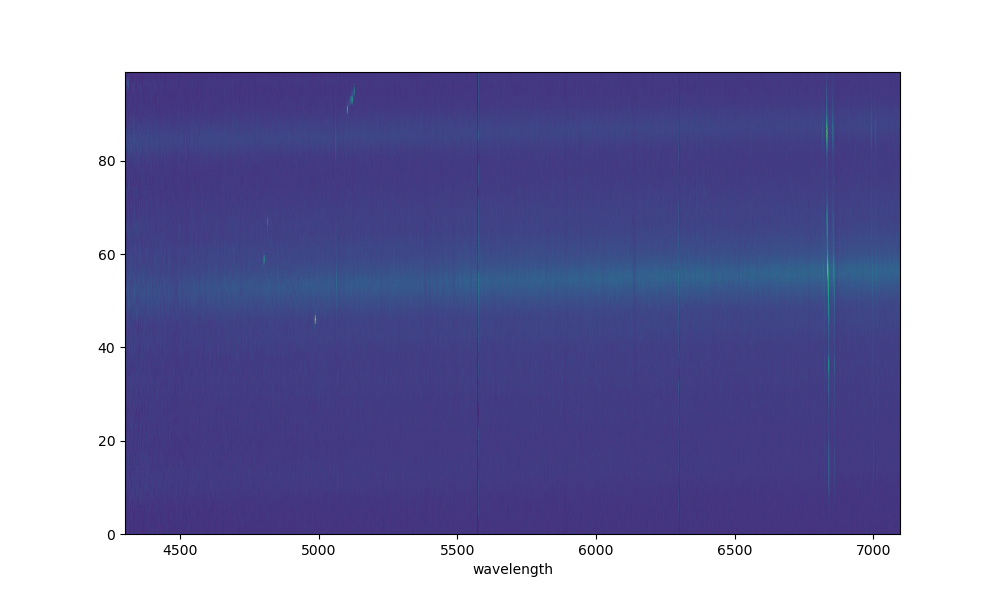

In [9]:
hdul2 = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/MGC+01-02-017/MGC+01-02-017_1/FORS2.2021-10-04T04_41_52.988/MCG+01-02-017_1_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul2.info()
image2 = hdul2[0].data
image_cut2 = image2[61:161, 0:1890]

x_grid, y_grid = np.meshgrid(wv, y)
plt.figure(figsize=(10, 6))
plt.pcolormesh(x_grid, y_grid, image_cut2, shading='gouraud')#, vmin = np.percentile(image_cut, 20), vmax = 0.16)
plt.xlabel('wavelength')

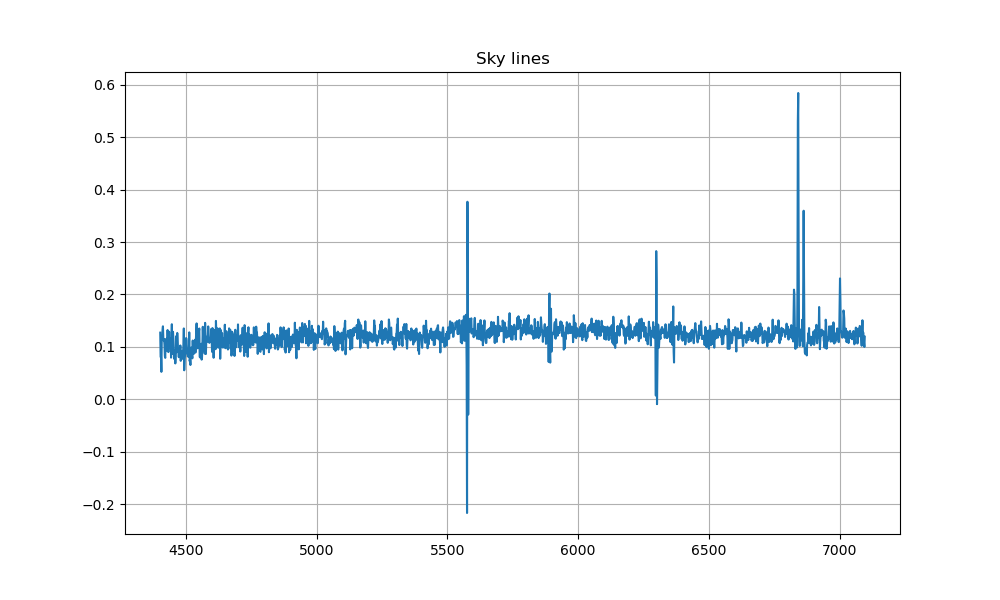

In [10]:
mask_sky = (y > 15)*(y < 25)
mask_wv = wv > 4400
image_sky = image_cut2[np.ix_(mask_sky, mask_wv)]
radial_profile_sky = np.sum(image_sky, axis = 0)
plt.figure(figsize=(10, 6))
plt.plot(wv[mask_wv], radial_profile_sky)
#x_interval = np.arange(4300, 4300+1800*1.48, 250)
#plt.xticks(x_interval)
plt.grid()
plt.title(r'Sky lines')

plt.savefig('Sky_lines')

## H$\alpha$

Text(0.5, 1.0, 'H$\\alpha$')

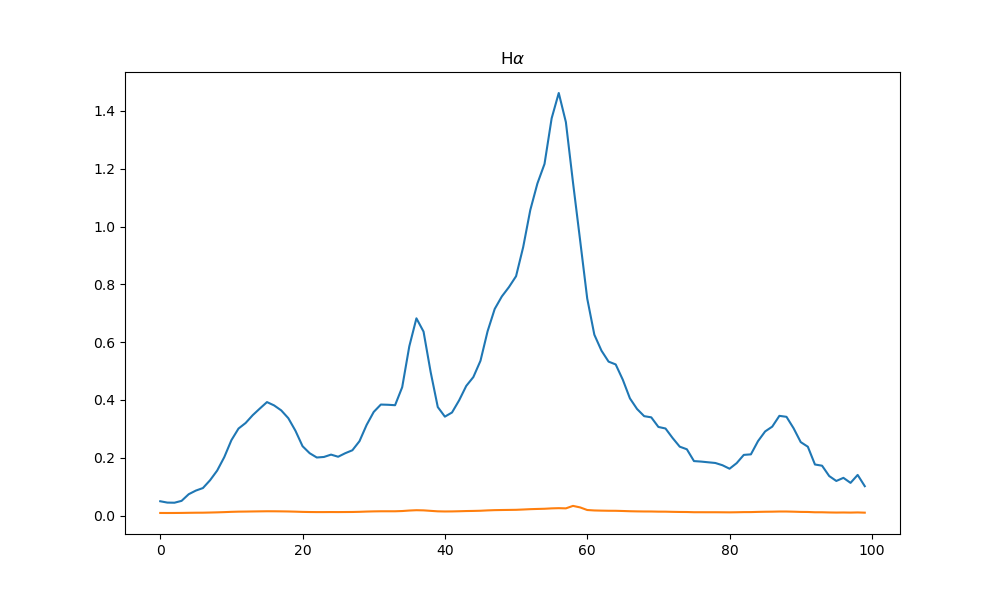

In [11]:
mask_HA = (wv > l_HA-8)*(wv < l_HA+8)
image_HA = image_cut[:, mask_HA]
image_error_HA = image_error_cut[:, mask_HA]
radial_profile_HA = np.sum(image_HA, axis = 1)
radial_profile_error_HA = np.sqrt(np.sum(image_error_HA**2, axis = 1))

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_HA)
plt.plot(x_axes, radial_profile_error_HA)
plt.title(r'H$\alpha$')

In [40]:
def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16]) +
        sersic_1d(x_hr, *params[16:20])+ 
        sersic_1d(x_hr, *params[20:24])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs):
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

def sersic_1d_convolved(x, I_e, r_e, n, x_0):
    """ Sérsic convoluto con PSF gaussiana """
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = sersic_1d(x_hr, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def plot_curve(x_axes, params_curve, radial_profile):
    y_fit = model_convolved(x_axes, *params_curve)
    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[0:4]), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[4:8]), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[8:12]), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[12:16]), color='orange', linestyle='--', label='Sérsic 4')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[16:20]), color = 'chocolate', linestyle='--', label='Sérsic 5')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[20:24]), color = 'purple', linestyle='--', label='Sérsic 6')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(r"Radial profile H$\alpha$")
    ax[0].legend()
    ax[0].grid(True)
    ax[0].set_ylim(0, 80.5)
    #ax[0].tight_layout()
    
    ax[1].scatter(x_axes, (radial_profile - y_fit)/radial_profile_error_HA, marker = '+')
    ax[1].axhline(0, color ='red', linestyle ='dashed')
    ax[1].set_ylabel(r'$\chi$')

def plot_diff(x_axes, best_params, radial_profile):
    y_fit = model_convolved(x_axes, *best_params)

    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[0:4]), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[4:8]), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[8:12]), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[12:16]), color='orange', linestyle='--', label='Sérsic 4')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[16:20]), color = 'chocolate', linestyle='--', label='Sérsic 5')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[20:24]), color = 'purple', linestyle='--', label='Sérsic 6')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(r"Radial profile H$\alpha$")
    ax[0].legend()
    ax[0].grid(True)
    ax[0].set_ylim(0, 80.5)
    #ax[0].tight_layout()
    
    ax[1].plot(x_axes, radial_profile - y_fit)
    ax[1].set_ylim(-0.2, 0.2)

In [41]:
# Bounds:
bounds = [
    (0, 1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (10, 20),   # x_0: posizione da 0 a 100

    (0, 1),
    (0, 50),
    (0.1, 10),
    (35, 45),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (55, 65),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (60, 70),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (70, 80),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (90, 100)
]

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 14248.609601069687
differential_evolution step 2: f(x)= 14248.609601069687
differential_evolution step 3: f(x)= 14248.609601069687
differential_evolution step 4: f(x)= 13279.109052288788
differential_evolution step 5: f(x)= 13279.109052288788
differential_evolution step 6: f(x)= 12546.580201670416
differential_evolution step 7: f(x)= 12546.580201670416
differential_evolution step 8: f(x)= 8674.676562284489
differential_evolution step 9: f(x)= 8011.211697296666
differential_evolution step 10: f(x)= 8011.211697296666
differential_evolution step 11: f(x)= 8011.211697296666
differential_evolution step 12: f(x)= 8011.211697296666
differential_evolution step 13: f(x)= 8011.211697296666
differential_evolution step 14: f(x)= 8011.211697296666
differential_evolution step 15: f(x)= 8011.211697296666
differential_evolution step 16: f(x)= 8011.211697296666
differential_evolution step 17: f(x)= 7773.5366620410305
differential_evolution step 18: f(x)= 7773.536662

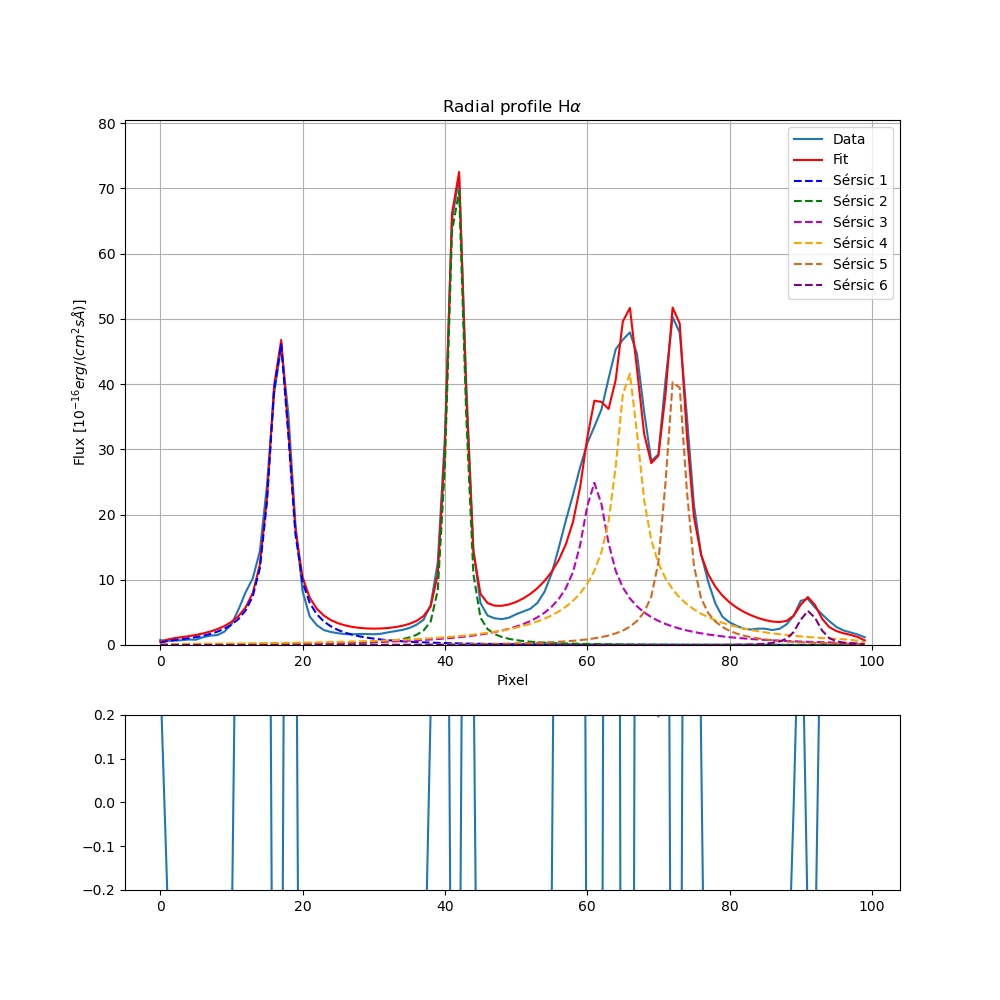

In [42]:
plot_diff(x_axes, best_params, radial_profile_HA)
plt.savefig('Radial_profile_Halpha_diff')

In [43]:
params_curve_HA, covariance_HA = curve_fit(model_convolved, x_axes, radial_profile_HA, p0=result.x, sigma = radial_profile_error_HA)

print("Optimize parameters with curve fit:")

n_component = 6
I_e = np.zeros(n_component)
r_e = np.zeros(n_component)
n = np.zeros(n_component)
x_0_HA = np.zeros(n_component)

I_e_err = np.zeros(n_component)
r_e_err = np.zeros(n_component)
n_err = np.zeros(n_component)
x_0_err = np.zeros(n_component)

for i in range(n_component):
    I_e[i], r_e[i], n[i], x_0_HA[i] = params_curve_HA[i*4:(i+1)*4]
    I_e_err[i] = np.sqrt(np.diag(covariance_HA)[i*4])
    r_e_err[i] = np.sqrt(np.diag(covariance_HA)[(i*4)+1])
    n_err[i] = np.sqrt(np.diag(covariance_HA)[(i*4)+2])
    x_0_err[i] = np.sqrt(np.diag(covariance_HA)[(i*4)+3])
    print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0_HA[i]:.4f}")

print(np.sqrt(np.diag(covariance_HA)))
#print(infodict.fvec**2)
chi2_HA = np.sum((((radial_profile_HA - model_convolved(x_axes, *params_curve_HA)) / radial_profile_error_HA)**2))
dof_HA = len(radial_profile_HA) - len(params_curve_HA)
chi2_reduced_HA = chi2_HA / dof_HA
print(chi2_reduced_HA)

d1 = { 'Component 1': [I_e[0], r_e[0], n[0], x_0_HA[0]], 'Component 2': [I_e[1], r_e[1], n[1], x_0_HA[1]], 
       'Component 3': [I_e[2], r_e[2], n[2], x_0_HA[2]], 'Component 4': [I_e[3], r_e[3], n[3], x_0_HA[3]], 
       'Component 5': [I_e[4], r_e[4], n[4], x_0_HA[4]], 'Component 6': [I_e[5], r_e[5], n[5], x_0_HA[5]]}
df1 = pd.DataFrame(data=d1, index =  ['I_e', 'r_e', 'n', 'x_0'])
df1.to_csv("Halpha_fit.csv", float_format='%.4f')

d2 = { 'Component 1': [I_e_err[0], r_e_err[0], n_err[0], x_0_err[0]], 'Component 2': [I_e_err[1], r_e_err[1], n_err[1], x_0_err[1]], 
       'Component 3': [I_e_err[2], r_e_err[2], n_err[2], x_0_err[2]], 'Component 4': [I_e_err[3], r_e_err[3], n_err[3], x_0_err[3]], 
       'Component 5': [I_e_err[4], r_e_err[4], n_err[4], x_0_err[4]], 'Component 6': [I_e_err[5], r_e_err[5], n_err[5], x_0_err[5]]}
df2 = pd.DataFrame(data=d2, index =  ['I_e error', 'r_e error', 'n error', 'x_0 error'])
df2.to_csv("Halpha_fit_error.csv", float_format='%.4f')

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_16504\3610827238.py:9: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_16504\3610827238.py:22: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Optimize parameters with curve fit:
Sérsic 1: I_e=4.3569, r_e=4.7711, n=1.8888, x_0=16.6651
Sérsic 2: I_e=0.0956, r_e=41.6616, n=6.3759, x_0=41.5849
Sérsic 3: I_e=9.9376, r_e=5.7055, n=0.7870, x_0=60.7174
Sérsic 4: I_e=26.6265, r_e=1.9644, n=0.2280, x_0=65.7194
Sérsic 5: I_e=10.4510, r_e=3.7204, n=1.1666, x_0=72.3762
Sérsic 6: I_e=0.0328, r_e=169.2158, n=3.4762, x_0=90.9790
[1.53281672e+00 1.12164760e+00 2.90211696e-01 4.39508252e-02
 2.74526828e-01 7.97770122e+01 3.10900535e+00 2.65082651e-02
 2.38257709e+00 3.82210679e-01 1.26740247e-01 7.20188778e-01
 4.63048171e+00 2.40857663e-01 2.01515395e-01 2.28767181e-01
 1.86646835e+00 4.14640143e-01 1.43049569e-01 7.23186594e-02
 2.77373959e-01 1.21641615e+03 6.10918051e+00 9.24187609e-03]
19.766524379095443


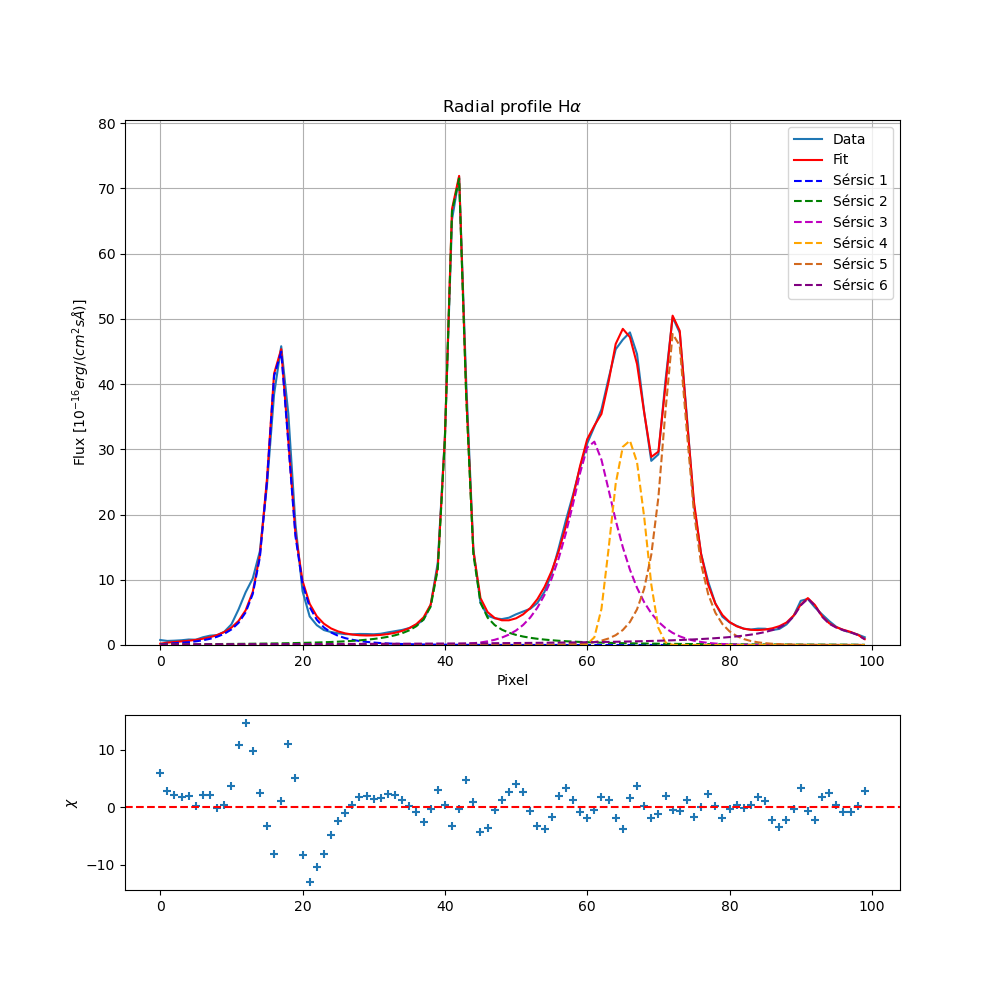

In [44]:
plot_curve(x_axes, params_curve_HA, radial_profile_HA)
plt.savefig('Radial_profile_Halpha_curve')

## H$\beta$

Text(0.5, 1.0, 'H$\\beta$')

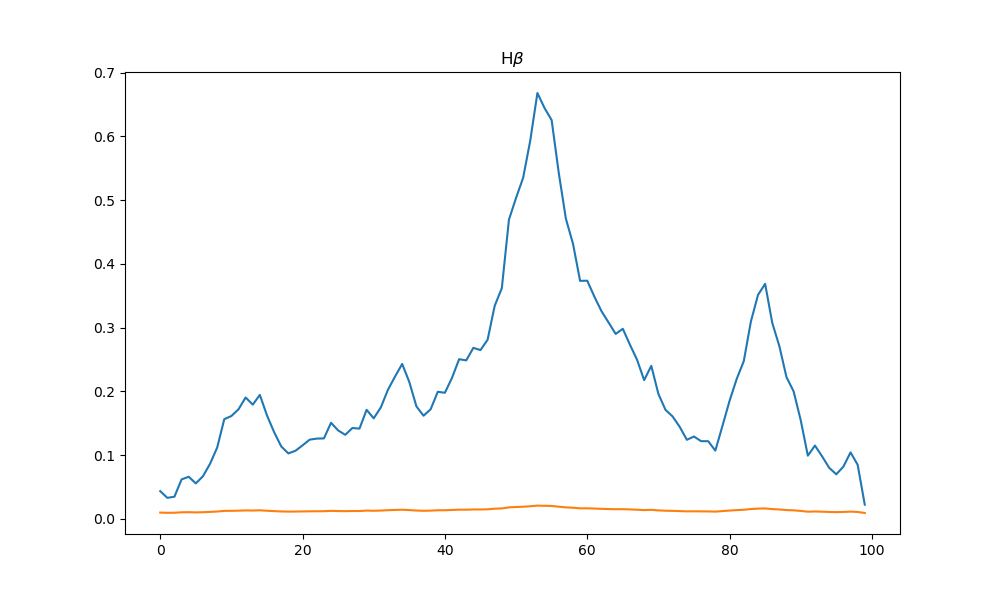

In [15]:
mask_HB = (wv > l_HB-8)*(wv < l_HB+8)
image_HB = image_cut[:, mask_HB] 
image_error_HB = image_error_cut[:, mask_HB]
radial_profile_HB = np.sum(image_HB, axis = 1)
radial_profile_error_HB = np.sqrt(np.sum(image_error_HB**2, axis = 1))

plt.figure(figsize=(10, 6))
x_axes = np.arange(0, 100, 1)
plt.plot(x_axes, radial_profile_HB)
plt.plot(x_axes, radial_profile_error_HB)
plt.title(r'H$\beta$')

In [ ]:
# Bounds:
bounds = [
    (0, 1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (x_0_HA[0]-1.5, x_0_HA[0]+1.5),   # x_0: circa la posizione di Halpha

    (0, 1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[1]-1.5, x_0_HA[1]+1.5),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[2]-1.5, x_0_HA[2]+1.5),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[3]-1.5, x_0_HA[3]+1.5),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[4]-1.5, x_0_HA[4]+1.5),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[5]-1.5, x_0_HA[5]+1.5)
]

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HB)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 3875.991521283106
differential_evolution step 2: f(x)= 2808.3147462801785
differential_evolution step 3: f(x)= 2808.3147462801785


In [ ]:
plot_diff(x_axes, best_params, radial_profile_HB)
plt.savefig('Radial_profile_Hbeta_kernel')

In [ ]:
params_curve_HB, covariance_HB = curve_fit(model_convolved, x_axes, radial_profile_HB, p0=result.x, sigma = radial_profile_error_HB)

I_e = np.zeros(n_component)
r_e = np.zeros(n_component)
n = np.zeros(n_component)
x_0_HA = np.zeros(n_component)

I_e_err = np.zeros(n_component)
r_e_err = np.zeros(n_component)
n_err = np.zeros(n_component)
x_0_err = np.zeros(n_component)

for i in range(n_component):
    I_e[i], r_e[i], n[i], x_0[i] = params_curve_HB[i*4:(i+1)*4]
    I_e_err[i] = np.sqrt(np.diag(covariance_HB)[i*4])
    r_e_err[i] = np.sqrt(np.diag(covariance_HB)[(i*4)+1])
    n_err[i] = np.sqrt(np.diag(covariance_HB)[(i*4)+2])
    x_0_err[i] = np.sqrt(np.diag(covariance_HB)[(i*4)+3])
    print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

d1 = { 'Component 1': [I_e[0], r_e[0], n[0], x_0_HA[0]], 'Component 2': [I_e[1], r_e[1], n[1], x_0_HA[1]], 
       'Component 3': [I_e[2], r_e[2], n[2], x_0_HA[2]], 'Component 4': [I_e[3], r_e[3], n[3], x_0_HA[3]], 
       'Component 5': [I_e[4], r_e[4], n[4], x_0_HA[4]], 'Component 6': [I_e[5], r_e[5], n[5], x_0_HA[5]]}
df1 = pd.DataFrame(data=d1, index =  ['I_e', 'r_e', 'n', 'x_0'])
df1.to_csv("Hbeta_fit.csv", float_format='%.4f')

d2 = { 'Component 1': [I_e_err[0], r_e_err[0], n_err[0], x_0_err[0]], 'Component 2': [I_e_err[1], r_e_err[1], n_err[1], x_0_err[1]], 
       'Component 3': [I_e_err[2], r_e_err[2], n_err[2], x_0_err[2]], 'Component 4': [I_e_err[3], r_e_err[3], n_err[3], x_0_err[3]], 
       'Component 5': [I_e_err[4], r_e_err[4], n_err[4], x_0_err[4]], 'Component 6': [I_e_err[5], r_e_err[5], n_err[5], x_0_err[5]]}
df2 = pd.DataFrame(data=d2, index =  ['I_e error', 'r_e error', 'n error', 'x_0 error'])
df2.to_csv("Hbeta_fit_error.csv", float_format='%.4f')

#print(covariance)
print(np.sqrt(np.diag(covariance_HB)))
#print(infodict.fvec**2)
chi2_HB = np.sum((((radial_profile_HB - model_convolved(x_axes, *params_curve_HB)) / radial_profile_error_HB)**2))
dof_HB = len(radial_profile_HB) - len(params_curve_HB)
chi2_reduced_HB = chi2_HB / dof_HB
print(chi2_reduced_HB)

In [ ]:
# Plots:
plot_curve(x_axes, params_curve_HB, radial_profile_HB)
plt.savefig('Radial_profile_Hbeta_curve')

## [NII]

In [ ]:
mask_NII = (wv > l_NII-8)*(wv < l_NII+8)
image_NII = image_cut[:, mask_NII]
image_error_NII = image_error_cut[:, mask_NII]
radial_profile_NII = np.sum(image_NII, axis = 1)
radial_profile_error_NII = np.sqrt(np.sum(image_error_NII**2, axis = 1))

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_NII)
plt.plot(x_axes, radial_profile_error_NII)
plt.title(r'[NII]')

In [ ]:
# Bounds:
bounds = [
    (0, 1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (x_0_HA[0]-1.5, x_0_HA[0]+1.5),   # x_0: circa la posizione di Halpha

    (0, 1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[1]-1.5, x_0_HA[1]+1.5),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[2]-1.5, x_0_HA[2]+1.5),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[3]-1.5, x_0_HA[3]+1.5),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[4]-1.5, x_0_HA[4]+1.5),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[5]-1.5, x_0_HA[5]+1.5)
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_NII)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

In [ ]:
# Plots:
plot_diff(x_axes, best_params, radial_profile_NII)
plt.savefig('Radial_profile_NII_kernel')

In [ ]:
params_curve_NII, covariance_NII = curve_fit(model_convolved, x_axes, radial_profile_NII, p0=result.x, sigma = radial_profile_error_NII)

I_e = np.zeros(n_component)
r_e = np.zeros(n_component)
n = np.zeros(n_component)
x_0_HA = np.zeros(n_component)

I_e_err = np.zeros(n_component)
r_e_err = np.zeros(n_component)
n_err = np.zeros(n_component)
x_0_err = np.zeros(n_component)

for i in range(n_component):
    I_e[i], r_e[i], n[i], x_0[i] = params_curve_NII[i*4:(i+1)*4]
    I_e_err[i] = np.sqrt(np.diag(covariance_NII)[i*4])
    r_e_err[i] = np.sqrt(np.diag(covariance_NII)[(i*4)+1])
    n_err[i] = np.sqrt(np.diag(covariance_NII)[(i*4)+2])
    x_0_err[i] = np.sqrt(np.diag(covariance_NII)[(i*4)+3])
    print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

d1 = { 'Component 1': [I_e[0], r_e[0], n[0], x_0_HA[0]], 'Component 2': [I_e[1], r_e[1], n[1], x_0_HA[1]], 
       'Component 3': [I_e[2], r_e[2], n[2], x_0_HA[2]], 'Component 4': [I_e[3], r_e[3], n[3], x_0_HA[3]], 
       'Component 5': [I_e[4], r_e[4], n[4], x_0_HA[4]], 'Component 6': [I_e[5], r_e[5], n[5], x_0_HA[5]]}
df1 = pd.DataFrame(data=d1, index =  ['I_e', 'r_e', 'n', 'x_0'])
df1.to_csv("NII_fit.csv", float_format='%.4f')

d2 = { 'Component 1': [I_e_err[0], r_e_err[0], n_err[0], x_0_err[0]], 'Component 2': [I_e_err[1], r_e_err[1], n_err[1], x_0_err[1]], 
       'Component 3': [I_e_err[2], r_e_err[2], n_err[2], x_0_err[2]], 'Component 4': [I_e_err[3], r_e_err[3], n_err[3], x_0_err[3]], 
       'Component 5': [I_e_err[4], r_e_err[4], n_err[4], x_0_err[4]], 'Component 6': [I_e_err[5], r_e_err[5], n_err[5], x_0_err[5]]}
df2 = pd.DataFrame(data=d2, index =  ['I_e error', 'r_e error', 'n error', 'x_0 error'])
df2.to_csv("NII_fit_error.csv", float_format='%.4f')

#print(covariance)
print(np.sqrt(np.diag(covariance_NII)))
#print(infodict.fvec**2)
chi2_NII = np.sum((((radial_profile_NII - model_convolved(x_axes, *params_curve_NII)) / radial_profile_error_NII)**2))
dof_NII = len(radial_profile_NII) - len(params_curve_NII)
chi2_reduced_NII = chi2_NII / dof_NII
print(chi2_reduced_NII)

In [ ]:
plot_curve(x_axes, params_curve_NII, radial_profile_NII)
plt.savefig('Radial_profile_NII_curve')

## [SII]

In [ ]:
mask_SII = (wv > l_SII-8)*(wv < l_SII+8)
x_axes = np.arange(0, 100, 1)
image_SII = image_cut[:, mask_SII] 
image_error_SII = image_error_cut[:, mask_SII]
radial_profile_SII = np.sum(image_SII, axis = 1)
radial_profile_error_SII = np.sqrt(np.sum(image_error_SII**2, axis = 1))

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_SII)
plt.plot(x_axes, radial_profile_error_SII)
plt.title(r'[SII]')

In [ ]:
# Bounds:
bounds = [
    (0, 1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (x_0_HA[0]-1.5, x_0_HA[0]+1.5),   # x_0: circa la posizione di Halpha

    (0, 1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[1]-1.5, x_0_HA[1]+1.5),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[2]-1.5, x_0_HA[2]+1.5),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[3]-1.5, x_0_HA[3]+1.5),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[4]-1.5, x_0_HA[4]+1.5),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[5]-1.5, x_0_HA[5]+1.5)
]

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_SII)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

In [ ]:
plot_diff(x_axes, best_params, radial_profile_SII)
plt.savefig('Radial_profile_SII_diff')

In [ ]:
params_curve_SII, covariance_SII = curve_fit(model_convolved, x_axes, radial_profile_SII, p0=result.x, sigma = radial_profile_error_SII)

I_e = np.zeros(n_component)
r_e = np.zeros(n_component)
n = np.zeros(n_component)
x_0_HA = np.zeros(n_component)

I_e_err = np.zeros(n_component)
r_e_err = np.zeros(n_component)
n_err = np.zeros(n_component)
x_0_err = np.zeros(n_component)

for i in range(n_component):
    I_e[i], r_e[i], n[i], x_0[i] = params_curve_SII[i*4:(i+1)*4]
    I_e_err[i] = np.sqrt(np.diag(covariance_SII)[i*4])
    r_e_err[i] = np.sqrt(np.diag(covariance_SII)[(i*4)+1])
    n_err[i] = np.sqrt(np.diag(covariance_SII)[(i*4)+2])
    x_0_err[i] = np.sqrt(np.diag(covariance_SII)[(i*4)+3])
    print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

d1 = { 'Component 1': [I_e[0], r_e[0], n[0], x_0_HA[0]], 'Component 2': [I_e[1], r_e[1], n[1], x_0_HA[1]], 
       'Component 3': [I_e[2], r_e[2], n[2], x_0_HA[2]], 'Component 4': [I_e[3], r_e[3], n[3], x_0_HA[3]], 
       'Component 5': [I_e[4], r_e[4], n[4], x_0_HA[4]], 'Component 6': [I_e[5], r_e[5], n[5], x_0_HA[5]]}
df1 = pd.DataFrame(data=d1, index =  ['I_e', 'r_e', 'n', 'x_0'])
df1.to_csv("SII_fit.csv", float_format='%.4f')

d2 = { 'Component 1': [I_e_err[0], r_e_err[0], n_err[0], x_0_err[0]], 'Component 2': [I_e_err[1], r_e_err[1], n_err[1], x_0_err[1]], 
       'Component 3': [I_e_err[2], r_e_err[2], n_err[2], x_0_err[2]], 'Component 4': [I_e_err[3], r_e_err[3], n_err[3], x_0_err[3]], 
       'Component 5': [I_e_err[4], r_e_err[4], n_err[4], x_0_err[4]], 'Component 6': [I_e_err[5], r_e_err[5], n_err[5], x_0_err[5]]}
df2 = pd.DataFrame(data=d2, index =  ['I_e error', 'r_e error', 'n error', 'x_0 error'])
df2.to_csv("SII_fit_error.csv", float_format='%.4f')

#print(covariance)
print(np.sqrt(np.diag(covariance_SII)))
#print(infodict.fvec**2)
chi2_SII = np.sum((((radial_profile_SII - model_convolved(x_axes, *params_curve_SII)) / radial_profile_error_SII)**2))
dof_SII = len(radial_profile_SII) - len(params_curve_SII)
chi2_reduced_SII = chi2_SII / dof_SII
print(chi2_reduced_SII)

In [ ]:
# Plots:
plot_curve(x_axes, params_curve_SII, radial_profile_SII)
plt.savefig('Radial_profile_SII_curve')

## [OIII]

In [ ]:
mask_OIII = (wv > l_OIII-8)*(wv < l_OIII+8)
image_OIII = image_cut[:, mask_OIII] 
image_error_OIII = image_error_cut[:, mask_OIII]
radial_profile_OIII = np.sum(image_OIII, axis = 1)
radial_profile_error_OIII = np.sqrt(np.sum(image_error_OIII**2, axis = 1))

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_OIII)
plt.plot(x_axes, radial_profile_error_OIII)
plt.title(r'[OIII]')

In [ ]:
# Bounds:
bounds = [
    (0, 1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (x_0_HA[0]-1.5, x_0_HA[0]+1.5),   # x_0: circa la posizione di Halpha

    (0, 1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[1]-1.5, x_0_HA[1]+1.5),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[2]-1.5, x_0_HA[2]+1.5),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[3]-1.5, x_0_HA[3]+1.5),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[4]-1.5, x_0_HA[4]+1.5),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[5]-1.5, x_0_HA[5]+1.5)
]

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_OIII)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

In [ ]:
# Plots:
plot_diff(x_axes, best_params, radial_profile_OIII)
plt.savefig('Radial_profile_OIII_diff')

In [ ]:
params_curve_OIII, covariance_OIII = curve_fit(model_convolved, x_axes, radial_profile_OIII, p0=result.x, sigma = radial_profile_error_OIII)

I_e = np.zeros(n_component)
r_e = np.zeros(n_component)
n = np.zeros(n_component)
x_0_HA = np.zeros(n_component)

I_e_err = np.zeros(n_component)
r_e_err = np.zeros(n_component)
n_err = np.zeros(n_component)
x_0_err = np.zeros(n_component)

for i in range(n_component):
    I_e[i], r_e[i], n[i], x_0[i] = params_curve_OIII[i*4:(i+1)*4]
    I_e_err[i] = np.sqrt(np.diag(covariance_OIII)[i*4])
    r_e_err[i] = np.sqrt(np.diag(covariance_OIII)[(i*4)+1])
    n_err[i] = np.sqrt(np.diag(covariance_OIII)[(i*4)+2])
    x_0_err[i] = np.sqrt(np.diag(covariance_OIII)[(i*4)+3])
    print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

d1 = { 'Component 1': [I_e[0], r_e[0], n[0], x_0_HA[0]], 'Component 2': [I_e[1], r_e[1], n[1], x_0_HA[1]], 
       'Component 3': [I_e[2], r_e[2], n[2], x_0_HA[2]], 'Component 4': [I_e[3], r_e[3], n[3], x_0_HA[3]], 
       'Component 5': [I_e[4], r_e[4], n[4], x_0_HA[4]], 'Component 6': [I_e[5], r_e[5], n[5], x_0_HA[5]]}
df1 = pd.DataFrame(data=d1, index =  ['I_e', 'r_e', 'n', 'x_0'])
df1.to_csv("OIII_fit.csv", float_format='%.4f')

d2 = { 'Component 1': [I_e_err[0], r_e_err[0], n_err[0], x_0_err[0]], 'Component 2': [I_e_err[1], r_e_err[1], n_err[1], x_0_err[1]], 
       'Component 3': [I_e_err[2], r_e_err[2], n_err[2], x_0_err[2]], 'Component 4': [I_e_err[3], r_e_err[3], n_err[3], x_0_err[3]], 
       'Component 5': [I_e_err[4], r_e_err[4], n_err[4], x_0_err[4]], 'Component 6': [I_e_err[5], r_e_err[5], n_err[5], x_0_err[5]]}
df2 = pd.DataFrame(data=d2, index =  ['I_e error', 'r_e error', 'n error', 'x_0 error'])
df2.to_csv("OIII_fit_error.csv", float_format='%.4f')

#print(covariance)
print(np.sqrt(np.diag(covariance_OIII)))
#print(infodict.fvec**2)
chi2_OIII = np.sum((((radial_profile_OIII - model_convolved(x_axes, *params_curve_OIII)) / radial_profile_error_OIII)**2))
dof_OIII = len(radial_profile_OIII) - len(params_curve_OIII)
chi2_reduced_OIII = chi2_OIII / dof_OIII
print(chi2_reduced_OIII)

In [ ]:
plot_curve(x_axes, params_curve_OIII, radial_profile_OIII)
plt.savefig('Radial_profile_OIII_curve')

## Continuum 1

In [ ]:
mask_continuum_1 = (wv > 4500)*(wv < 4800)
image_continuum_1 = image_cut[:, mask_continuum_1]
image_error_continuum_1 = image_error_cut[:, mask_continuum_1]
radial_profile_continuum_1 = np.sum(image_continuum_1, axis = 1)
radial_profile_error_continuum_1 = np.sqrt(np.sum(image_error_continuum_1**2, axis = 1))

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_1)
plt.plot(x_axes, radial_profile_error_continuum_1)
plt.title(r'Continuum 1')

In [ ]:
# Bounds:
bounds = [
    (0, 1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (10, 20),   # x_0: posizione da 0 a 100

    (0, 1),
    (0, 50),
    (0.1, 10),
    (35, 45),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (55, 65),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (60, 70),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (70, 80),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (90, 100)
]

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_1)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

In [ ]:
# Plots:
plot_diff(x_axes, best_params, radial_profile_continuum_1)
plt.savefig('Radial_profile_continuum_1_diff')

In [ ]:
params_curve_continuum_1, covariance_continuum_1 = curve_fit(model_convolved, x_axes, radial_profile_continuum_1, p0=result.x, sigma = radial_profile_error_continuum_1)

I_e = np.zeros(n_component)
r_e = np.zeros(n_component)
n = np.zeros(n_component)
x_0_HA = np.zeros(n_component)

I_e_err = np.zeros(n_component)
r_e_err = np.zeros(n_component)
n_err = np.zeros(n_component)
x_0_err = np.zeros(n_component)

for i in range(n_component):
    I_e[i], r_e[i], n[i], x_0[i] = params_curve_continuum_1[i*4:(i+1)*4]
    I_e_err[i] = np.sqrt(np.diag(covariance_continuum_1)[i*4])
    r_e_err[i] = np.sqrt(np.diag(covariance_continuum_1)[(i*4)+1])
    n_err[i] = np.sqrt(np.diag(covariance_continuum_1)[(i*4)+2])
    x_0_err[i] = np.sqrt(np.diag(covariance_continuum_1)[(i*4)+3])
    print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

d1 = { 'Component 1': [I_e[0], r_e[0], n[0], x_0_HA[0]], 'Component 2': [I_e[1], r_e[1], n[1], x_0_HA[1]], 
       'Component 3': [I_e[2], r_e[2], n[2], x_0_HA[2]], 'Component 4': [I_e[3], r_e[3], n[3], x_0_HA[3]], 
       'Component 5': [I_e[4], r_e[4], n[4], x_0_HA[4]], 'Component 6': [I_e[5], r_e[5], n[5], x_0_HA[5]]}
df1.to_csv("Continuum_1_fit.csv", float_format='%.4f')

d2 = { 'Component 1': [I_e_err[0], r_e_err[0], n_err[0], x_0_err[0]], 'Component 2': [I_e_err[1], r_e_err[1], n_err[1], x_0_err[1]], 
       'Component 3': [I_e_err[2], r_e_err[2], n_err[2], x_0_err[2]], 'Component 4': [I_e_err[3], r_e_err[3], n_err[3], x_0_err[3]], 
       'Component 5': [I_e_err[4], r_e_err[4], n_err[4], x_0_err[4]], 'Component 6': [I_e_err[5], r_e_err[5], n_err[5], x_0_err[5]]}
df2 = pd.DataFrame(data=d2, index =  ['I_e error', 'r_e error', 'n error', 'x_0 error'])
df2.to_csv("Continuum_1_fit_error.csv", float_format='%.4f')

#print(covariance)
print(np.sqrt(np.diag(covariance_continuum_1)))
#print(infodict.fvec**2)
chi2_continuum_1 = np.sum((((radial_profile_continuum_1 - model_convolved(x_axes, *params_curve_continuum_1)) / radial_profile_error_continuum_1)**2))
dof_continuum_1 = len(radial_profile_continuum_1) - len(params_curve_continuum_1)
chi2_reduced_continuum_1 = chi2_continuum_1 / dof_continuum_1
print(chi2_reduced_continuum_1)

In [ ]:
# Plots:
plot_curve(x_axes, params_curve_continuum_1, radial_profile_continuum_1)
plt.savefig('Radial_profile_continuum_1_curve')

## Continuum 2 

In [ ]:
mask_continuum_2 = (wv > 5300)*(wv < 5800)
image_continuum_2 = image_cut[:, mask_continuum_2]
image_error_continuum_2 = image_error_cut[:, mask_continuum_2]
radial_profile_continuum_2 = np.sum(image_continuum_2, axis = 1)
radial_profile_error_continuum_2 = np.sqrt(np.sum(image_error_continuum_2**2, axis = 1))

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_2)
plt.plot(x_axes, radial_profile_error_continuum_2)
plt.title(r'Continuum 2')

In [ ]:
# Bounds:
bounds = [
    (0, 1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (10, 20),   # x_0: posizione da 0 a 100

    (0, 1),
    (0, 50),
    (0.1, 10),
    (35, 45),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (55, 65),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (60, 70),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (70, 80),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (90, 100)
]

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_2)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

In [ ]:
plot_diff(x_axes, best_params, radial_profile_continuum_2)
plt.savefig('Radial_profile_continuum_2_diff')

In [ ]:
bounds = [
    (0, 1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (10, 20),   # x_0: posizione da 0 a 100

    (0, 1),
    (0, 50),
    (0.1, 10),
    (35, 45),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (55, 65),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (60, 70),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (70, 80),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (90, 100)
]

lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))

params_curve_continuum_2, covariance_continuum_2 = curve_fit(model_convolved, x_axes, radial_profile_continuum_2, p0=result.x, 
                                                             sigma = radial_profile_error_continuum_2, bounds = bounds_list, maxfev=15000)
I_e = np.zeros(n_component)
r_e = np.zeros(n_component)
n = np.zeros(n_component)
x_0_HA = np.zeros(n_component)

I_e_err = np.zeros(n_component)
r_e_err = np.zeros(n_component)
n_err = np.zeros(n_component)
x_0_err = np.zeros(n_component)

for i in range(n_component):
    I_e[i], r_e[i], n[i], x_0[i] = params_curve_continuum_2[i*4:(i+1)*4]
    I_e_err[i] = np.sqrt(np.diag(covariance_continuum_2)[i*4])
    r_e_err[i] = np.sqrt(np.diag(covariance_continuum_2)[(i*4)+1])
    n_err[i] = np.sqrt(np.diag(covariance_continuum_2)[(i*4)+2])
    x_0_err[i] = np.sqrt(np.diag(covariance_continuum_2)[(i*4)+3])
    print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

d1 = { 'Component 1': [I_e[0], r_e[0], n[0], x_0_HA[0]], 'Component 2': [I_e[1], r_e[1], n[1], x_0_HA[1]], 
       'Component 3': [I_e[2], r_e[2], n[2], x_0_HA[2]], 'Component 4': [I_e[3], r_e[3], n[3], x_0_HA[3]], 
       'Component 5': [I_e[4], r_e[4], n[4], x_0_HA[4]], 'Component 6': [I_e[5], r_e[5], n[5], x_0_HA[5]]}
df1 = pd.DataFrame(data=d1, index =  ['I_e', 'r_e', 'n', 'x_0'])
df1.to_csv("Continuum_2_fit.csv", float_format='%.4f')

d2 = { 'Component 1': [I_e_err[0], r_e_err[0], n_err[0], x_0_err[0]], 'Component 2': [I_e_err[1], r_e_err[1], n_err[1], x_0_err[1]], 
       'Component 3': [I_e_err[2], r_e_err[2], n_err[2], x_0_err[2]], 'Component 4': [I_e_err[3], r_e_err[3], n_err[3], x_0_err[3]], 
       'Component 5': [I_e_err[4], r_e_err[4], n_err[4], x_0_err[4]], 'Component 6': [I_e_err[5], r_e_err[5], n_err[5], x_0_err[5]]}
df2 = pd.DataFrame(data=d2, index =  ['I_e error', 'r_e error', 'n error', 'x_0 error'])
df2.to_csv("Continuum_2_fit_error.csv", float_format='%.4f')

#print(covariance)
print(np.sqrt(np.diag(covariance_continuum_2)))
#print(infodict.fvec**2)
chi2_continuum_2 = np.sum((((radial_profile_continuum_2 - model_convolved(x_axes, *params_curve_continuum_2)) / radial_profile_error_continuum_2)**2))
dof_continuum_2 = len(radial_profile_continuum_2) - len(params_curve_continuum_2)
chi2_reduced_continuum_2 = chi2_continuum_2 / dof_continuum_2
print(chi2_reduced_continuum_2)

In [ ]:
plot_curve(x_axes, params_curve_continuum_2, radial_profile_continuum_2)
plt.savefig('Radial_profile_continuum_2_curve')

##  Continuum 3

In [ ]:
mask_continuum_3 = (wv > 6400)*(wv < 6700)
image_continuum_3 = image_cut[:, mask_continuum_3]
image_error_continuum_3 = image_error_cut[:, mask_continuum_3]
radial_profile_continuum_3 = np.sum(image_continuum_3, axis = 1)
radial_profile_error_continuum_3 = np.sqrt(np.sum(image_error_continuum_3**2, axis = 1))

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_3)
plt.plot(x_axes, radial_profile_error_continuum_3)
plt.title(r'Continuum 3')

In [ ]:
# Bounds:
bounds = [
    (0, 1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (10, 20),   # x_0: posizione da 0 a 100

    (0, 1),
    (0, 50),
    (0.1, 10),
    (35, 45),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (55, 65),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (60, 70),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (70, 80),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (90, 100)
]

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_3)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

In [ ]:
plot_diff(x_axes, best_params, radial_profile_continuum_3)
plt.savefig('Radial_profile_continuum_3_diff')

In [ ]:
params_curve_continuum_3, covariance_continuum_3 = curve_fit(model_convolved, x_axes, radial_profile_continuum_3, p0=result.x, sigma = radial_profile_error_continuum_3)

I_e = np.zeros(n_component)
r_e = np.zeros(n_component)
n = np.zeros(n_component)
x_0_HA = np.zeros(n_component)

I_e_err = np.zeros(n_component)
r_e_err = np.zeros(n_component)
n_err = np.zeros(n_component)
x_0_err = np.zeros(n_component)

for i in range(n_component):
    I_e[i], r_e[i], n[i], x_0[i] = params_curve_continuum_3[i*4:(i+1)*4]
    I_e_err[i] = np.sqrt(np.diag(covariance_continuum_3)[i*4])
    r_e_err[i] = np.sqrt(np.diag(covariance_continuum_3)[(i*4)+1])
    n_err[i] = np.sqrt(np.diag(covariance_continuum_3)[(i*4)+2])
    x_0_err[i] = np.sqrt(np.diag(covariance_continuum_3)[(i*4)+3])
    print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

d1 = { 'Component 1': [I_e[0], r_e[0], n[0], x_0_HA[0]], 'Component 2': [I_e[1], r_e[1], n[1], x_0_HA[1]], 
       'Component 3': [I_e[2], r_e[2], n[2], x_0_HA[2]], 'Component 4': [I_e[3], r_e[3], n[3], x_0_HA[3]], 
       'Component 5': [I_e[4], r_e[4], n[4], x_0_HA[4]], 'Component 6': [I_e[5], r_e[5], n[5], x_0_HA[5]]}
df1.to_csv("Continuum_3_fit.csv", float_format='%.4f')

d2 = { 'Component 1': [I_e_err[0], r_e_err[0], n_err[0], x_0_err[0]], 'Component 2': [I_e_err[1], r_e_err[1], n_err[1], x_0_err[1]], 
       'Component 3': [I_e_err[2], r_e_err[2], n_err[2], x_0_err[2]], 'Component 4': [I_e_err[3], r_e_err[3], n_err[3], x_0_err[3]], 
       'Component 5': [I_e_err[4], r_e_err[4], n_err[4], x_0_err[4]], 'Component 6': [I_e_err[5], r_e_err[5], n_err[5], x_0_err[5]]}
df2 = pd.DataFrame(data=d2, index =  ['I_e error', 'r_e error', 'n error', 'x_0 error'])
df2.to_csv("Continuum_3_fit_error.csv", float_format='%.4f')

#print(covariance)
print(np.sqrt(np.diag(covariance_continuum_3)))
#print(infodict.fvec**2)
chi2_continuum_3 = np.sum((((radial_profile_continuum_3 - model_convolved(x_axes, *params_curve_continuum_3)) / radial_profile_error_continuum_3)**2))
dof_continuum_3 = len(radial_profile_continuum_3) - len(params_curve_continuum_3)
chi2_reduced_continuum_3 = chi2_continuum_3 / dof_continuum_3
print(chi2_reduced_continuum_3)

In [ ]:
plot_diff(x_axes, params_curve_continuum_3, radial_profile_continuum_3)
plt.savefig('Radial_profile_continuum_3_curve')

## Chi squared save

In [ ]:
chi_red = [chi2_reduced_HA, chi2_reduced_HB, chi2_reduced_NII, chi2_reduced_SII, chi2_reduced_OIII, 
           chi2_reduced_continuum_1, chi2_reduced_continuum_2, chi2_reduced_continuum_3]
dof = [dof_HA, dof_HB, dof_NII, dof_SII, dof_OIII, 
           dof_continuum_1, dof_continuum_2, dof_continuum_3]
chi = [chi2_HA, chi2_HB, chi2_NII, chi2_SII, chi2_OIII, 
           chi2_continuum_1, chi2_continuum_2, chi2_continuum_3]

d1 = {'Name': ['Halpha', 'Hbeta', 'NII', 'SII', 'OIII', 'Continuum 1', 'Continuum 2', 'Continuum 3'], 'Chi squared': chi,
      'Dof': dof, 'Chi reduced': chi_red}
df1 = pd.DataFrame(data=d1)
df1.to_csv("Chi_squared_curve_fit.csv", index= False)